In [1]:
%reload_ext autoreload
%autoreload 2

In [73]:
import jax
import jax.numpy as jnp
import numpy as np

import matplotlib.pyplot as plt

from flax import nnx

plt.style.use('pyloric_black.mplstyle')

Duplicate key in file 'pyloric_black.mplstyle', line 65 ('savefig.facecolor    : black       # Ensures black background when saving')


In [3]:
from diffusion_mri_models import Dti, Ball, Stick, add_mri_noise, normal_to_beta

In [4]:
from sympy import jn


class BallAndStick(nnx.Module, experimental_pytree=True):
    
    def __init__(self,num_sticks: int, rngs):
        self.num_sticks = num_sticks
        self.num_components = 1 + num_sticks + 1 # Ball + Sticks + Noise
        # Ball parameters
        self.theta_ball = nnx.Param(jax.random.normal(rngs.next(), (1)))
        self.phi_ball = nnx.Param(jax.random.normal(rngs.next(), (1)))

        self.thetas_stick = []
        self.phis_stick = []
    
        for i in range(num_sticks):
            self.thetas_stick.append(nnx.Param(jax.random.normal(rngs.next(), (3))))
            #if i < num_sticks-1:
            self.phis_stick.append(nnx.Param(jax.random.normal(rngs.next(), (1))))

        self.theta_sigma = nnx.Param(jax.random.normal(rngs.next(), (1)))

        

    def __call__(self, component_mask, bvals, bvecs, rng):
        ball = Ball.from_theta(self.theta_ball.value)
        sticks = [Stick.from_theta(theta) for theta in self.thetas_stick]


        phi0 = self.phi_ball.value
        phi1 = self.phis_stick[0].value
        phi2 = self.phis_stick[1].value 
        
        phis = jnp.concatenate([phi0, phi1, phi2])
        phis = jnp.where(component_mask[:-1] == 0, -jnp.inf, phis)
        phis_normalized = jax.nn.softmax(phis)
        
        S_ball = ball.signal(bvals, bvecs) * phis_normalized[0]
        S_total = S_ball

        for i, stick in enumerate(sticks):
            S_total += stick.signal(bvals, bvecs)*phis_normalized[i+1]
            

        std = jax.nn.sigmoid(self.theta_sigma.value)*0.1 * component_mask[-1]
        S_noisy = add_mri_noise(rng,S_total, std)

        return S_noisy


In [5]:
bvals = np.load('bvals.npy')
bvecs = np.load('bvecs.npy')

S_real = np.load("masked_data.npy")
b0_mask = bvals == 0

S0_real = np.mean(S_real[...,b0_mask], axis=-1, keepdims=True)
S_real = np.nan_to_num(S_real / S0_real)

/tmp/ipykernel_11636/2037590477.py:8: RuntimeWarning: divide by zero encountered in divide
  S_real = np.nan_to_num(S_real / S0_real)
/tmp/ipykernel_11636/2037590477.py:8: RuntimeWarning: invalid value encountered in divide
  S_real = np.nan_to_num(S_real / S0_real)


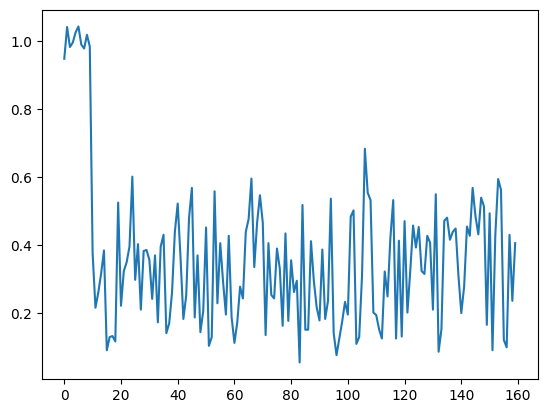

In [6]:
plt.plot(S_real[20,20,30])

In [14]:
simulator = BallAndStick(2, nnx.Rngs(10))

# bvals = jnp.array([0]*10 + [1000]*90)
# bvecs = jax.random.normal(jax.random.key(1), (100,3))
component_mask = jnp.array([1]*simulator.num_components)
component_mask

Array([1, 1, 1, 1], dtype=int32)

In [15]:
component_mask = jnp.array([1,1,1,1])
s = simulator(component_mask, bvals, bvecs, jax.random.key(15))

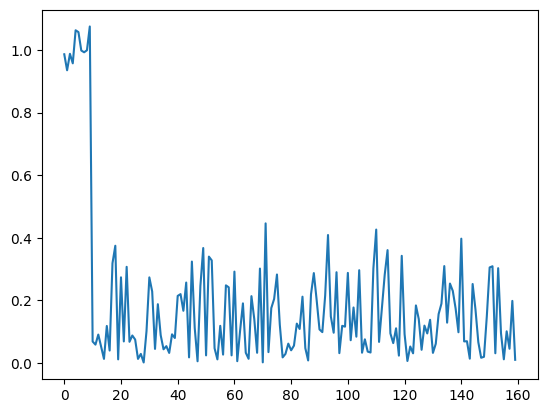

In [16]:
plt.plot(s)

In [87]:
graphdef, thetas = nnx.split(simulator, nnx.Param)
flat_thetas, unflatten = jax.flatten_util.ravel_pytree(thetas)

NUM_AQUISITIONS = len(bvals)

def generate_data(key):
    rng_component_mask, rng_params, rng_simulator = jax.random.split(key,3)
    component_mask = jax.random.bernoulli(rng_component_mask, 1., (simulator.num_components,))
    params = jax.random.normal(rng_params, flat_thetas.shape)
    params = unflatten(params)
    f = nnx.merge(graphdef, params)
    S = f(component_mask, bvals, bvecs, rng_simulator)
    return component_mask, params, S

flat_thetas


Array([-0.134, -0.513, -0.228,  0.624, -0.038,  0.039,  1.615, -1.961,
       -0.807, -0.387, -0.23 ], dtype=float32)

In [88]:
from functools import partial


@partial(jax.jit, static_argnums=(1,))  
def batch_sampler(key, batch_size=512):
    keys = jax.random.split(key, batch_size)
    components, thetas, signal= jax.vmap(lambda k:generate_data(k))(keys)
    xs = signal.reshape((batch_size, -1))
    return components, thetas, xs

def train_data_generator(key, batch_size):
    while True:
        key, subkey = jax.random.split(key)
        yield batch_sampler(subkey, batch_size)

train_data = train_data_generator(jax.random.PRNGKey(0), 1024)

In [19]:
from models import ModelIdentificationDecoder, MLP, Simformer, PyTreeTokenizer, EDM

In [20]:
import jax.flatten_util


_, thetas, xs = next(train_data)

thetas_flatten, tree = jax.tree_util.tree_flatten(thetas)
thetas_flat = jnp.concatenate(thetas_flatten, axis=-1)

In [ ]:
class EmbeddingNet(nnx.Module, experimental_pytree=True):
    def __init__(self, rngs):
        self.model = model
        self.params = params

In [21]:
embedding_net = MLP([NUM_AQUISITIONS, 200,200,100], rngs=nnx.Rngs(0))

dims_by_component = [1,1,1,1,1,3,3]
node_ids = list(range(len(dims_by_component)))
embed_nets = [nnx.Linear(dims_by_component[i], 100, rngs=nnx.Rngs(1),use_bias=False) for i in range(len(dims_by_component))]
decode_nets = [nnx.Linear(200, dims_by_component[i], rngs=nnx.Rngs(2),use_bias=False) for i in range(len(dims_by_component))]

tokenizer = PyTreeTokenizer(dims_by_component, embed_nets, decode_nets, rngs=nnx.Rngs(3), cond_dim=0, id_dim=100)
simformer = Simformer(tokenizer, nnx.Rngs(4), model_dim=200, context_embed=embedding_net, condition_dim=0, num_layers=5)

model = EDM(simformer)
params = nnx.state(model, nnx.Param)

In [22]:
components, thetas, xs = next(train_data)

In [89]:
import optax 

scheduler_lr = optax.cosine_onecycle_schedule(10_000, 5e-4)
optimizer = optax.chain(optax.adaptive_grad_clip(10.), optax.ema(0.01), optax.adam(scheduler_lr))

@jax.jit
def loss_fn(params, data, rng):
    components, thetas, xs = data
    thetas_flatten, tree = jax.tree_util.tree_flatten(thetas)
    thetas_flat = jnp.concatenate(thetas_flatten, axis=-1)
    loss = model.loss(params, rng=rng, data=thetas_flat, node_ids=node_ids, condition_mask=None,context=xs)


    return loss

@jax.jit
def update(params, opt_state, data, rng):
    grads = jax.grad(loss_fn)(params, data, rng)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state



In [90]:
opt_state = optimizer.init(params)

In [91]:
key = jax.random.PRNGKey(0)
for i in range(10_000):
    data = next(train_data)
    key, subkey = jax.random.split(key)
    params, opt_state = update(params, opt_state, data, subkey)
    if i % 100 == 0:
        print(loss_fn(params, data, subkey))

(1024, 160)
(1024, 1, 100) (1024, 1, 100)
(1024, 1, 200)
7.372115
7.2924385
7.13103
7.403255
7.1474886
7.149756
7.1238656
7.3672943
7.510416
7.176602
7.187518
7.346029
7.2919893
7.302179
7.1853123
7.3281627
7.480933
7.1511765
7.2760344
7.4833164
7.059111
7.4110117
7.2628355
7.621655
7.3591495
7.1283865
7.2683496
7.3561463
7.4396577
7.1050444
7.1874804
7.53168
7.229433
7.1169763
7.4771943
7.214074
7.378743
7.1897855
7.137865


KeyboardInterrupt: 

In [92]:
nnx.update(model, params)

In [119]:
components, thetas, xs = next(train_data)

In [120]:
from probjax.utils.odeint import odeint

def sample(rng, context):
    eps = jax.random.normal(rng, (11,)) * model.marginal_std(model.max_noise)
    ts = model.solve_schedule(100)

    def drift(t, x):
        t = jnp.atleast_1d(t)
        f = model.drift(t,x)
        g = model.diffusion(t, x)
        score = model.score(t,x, context=context, node_ids=node_ids, condition_mask=None)
        return (f -0.5*g**2*score).reshape(x.shape)

    return odeint(drift, eps,ts, method="heun")[-1]


from probjax.utils.sdeint import sdeint

def sample(rng, context):
    rng_init, rng_sample = jax.random.split(rng)
    eps = jax.random.normal(rng_init, (11,))  * model.marginal_std(model.max_noise)
    ts = model.solve_schedule(200)

    def drift(t, x):
        t = jnp.atleast_1d(t)
        f = model.drift(t,x)
        g = model.diffusion(t,x)
        score = model.score(t,x, context=context, node_ids=node_ids, condition_mask=None)

        drift_backward = f - g**2 * score
        return drift_backward
    
    def diffusion(t, x):
        t = jnp.atleast_1d(t)
        g = model.diffusion(t,x)
        return g
    
    return sdeint(rng_sample,drift, diffusion, eps, ts, method="euler_maruyama")[-1]
    

    
    

In [121]:
thetas_flatten, tree = jax.tree_util.tree_flatten(thetas)
thetas_flat = jnp.concatenate(thetas_flatten, axis=-1)

In [122]:
thetas_flat.shape

(1024, 11)

In [126]:
idx = 41

thetas_pred = jax.vmap(lambda k: sample(k, xs[idx]))(jax.random.split(jax.random.PRNGKey(0), 2000))



(160,)
(1, 100) (1, 100)
(1, 200)


In [127]:
from sbi.analysis import pairplot


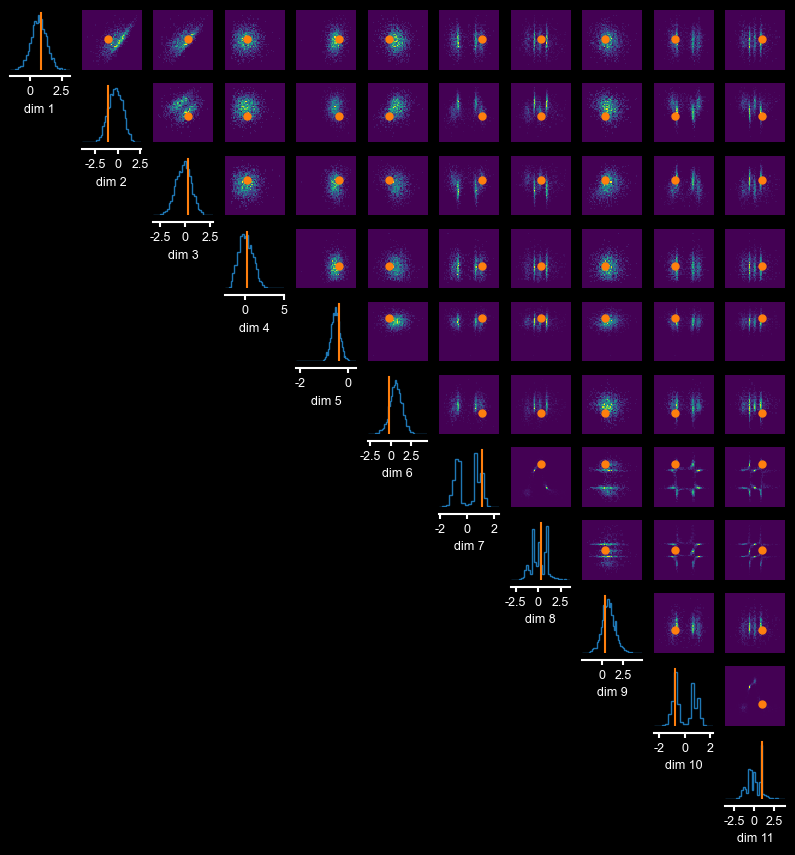

In [128]:
fig, axes = pairplot(thetas_pred, points=thetas_flat[idx][None])
fig.savefig("figures/pairplot_ball_and_sticks.png")

In [129]:
def pred(key, thetas):
    params = unflatten(thetas)
    f = nnx.merge(graphdef, params)
    S = f(component_mask, bvals, bvecs, key)
    return S

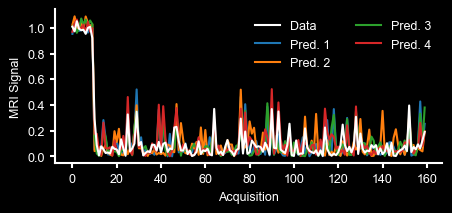

In [150]:
from matplotlib.pylab import f


S_pred = jax.vmap(pred)(jax.random.split(jax.random.key(0),2000), thetas_pred)


fig = plt.figure(figsize=(5,2))
l2 = plt.plot(S_pred[::500].T)
l1 = plt.plot(xs[idx], color="white")

plt.ylabel("MRI Signal")
plt.xlabel("Acquisition")

plt.legend([l1[0]] + l2, ["Data"] + [f"Pred. {i}" for i in range(1, 5)], ncol=2)
fig.savefig("figures/pred_ball_and_sticks.png")